# 01 - Model Evasion Across Three Modalities

**What is model evasion?** It perturbs a real input just enough to flip a
classifier's decision while staying close to the original: a fraudulent
transaction scored as legitimate, a handwritten digit misread, a negative review
classified as positive. The attacker only needs the model's `/predict` API - no
weights, no gradients, no training data.

**Why it matters (CIA).** Say you own a deployed classifier and want to understand
its security exposure:

- **Integrity** - evasion directly forges the model's output. A charge you should
  block is waved through; a control you deployed silently fails. The decision can no
  longer be trusted, which is the whole point of the model.
- **Confidentiality** - the queries that craft an evasion also map the decision
  boundary, leaking how the model separates classes (a stepping stone to extraction
  and to training-data inference).
- **Availability** - at scale, adversarial traffic degrades or bypasses the control
  the model was deployed to enforce, so it stops protecting the system in practice.

This notebook runs a decision-based evasion attack against **three published
Dreadnode environments**, one per modality, so you deploy nothing:

| Environment (`task_ref`)      | Modality | Attack               |
|-------------------------------|----------|----------------------|
| `ml-extraction-fraud-tabular` | tabular  | `hopskipjump_evasion`|
| `ml-extraction-mnist-image`   | image    | `hopskipjump_evasion`|
| `ml-extraction-imdb-text`     | text     | `pwws_evasion`       |

> **New here? Run [`00_prerequisites.ipynb`](../00_prerequisites.ipynb) first** -
> install the CLI (`curl -fsSL https://dreadnode.io/install.sh | bash`), sign in
> (`dn login`), and create a workspace. Everything below streams findings to your
> Dreadnode workspace and draws from your credit balance.

> **Follow along in the docs:** [Evasion - the Learning Guide](https://docs.dreadnode.io/ai-red-teaming/learning-guide/evasion) covers the concept, the threat model, and the defenses in depth.

## What we are assessing

We are going to assess the security of three production-style classifiers - a
credit-card **fraud** detector (tabular), a handwritten-**digit** recognizer
(image), and a movie-review **sentiment** model (text). For each one we take a
real sample the model gets right, run a black-box **evasion** attack that only
queries the prediction API, and confirm we can flip the decision with a minimal
change.

Each modality below follows the same three steps so it is easy to follow along:

1. **The original sample** - what the model sees and gets right.
2. **The attack** - the black-box search that hunts for a perturbation.
3. **The adversarial sample + metrics** - the flipped decision and what it cost.

Tabular first, then image, then text. Environments stay up until the final
**Clean up** cell so you can inspect everything during the walk-through.

## Setup

`dn.configure` uses your `dn login` profile - no secrets in the notebook.

In [1]:
PROJECT = "airt-learning-01-evasion"
ORG = "your-org-slug"  # your workspace slug from the platform URL  # your workspace slug from the platform URL
WORKSPACE = "main"

In [2]:
import dreadnode as dn

instance = dn.configure(project=PROJECT, workspace=WORKSPACE, organization=ORG, console=False)
api = instance.api
print("configured; findings stream to project:", PROJECT)

configured; findings stream to project: airt-learning-01-evasion


In [3]:
from dreadnode.airt import PredictionTargetSpec, hopskipjump_evasion, pwws_evasion
from dreadnode.airt.assessment import Assessment

## Target setup + helpers

The targets are **hosted Dreadnode environments** - `provision` boots one and waits
until its classifier answers (it prints the live URL). You can instead point
`make_spec` at any custom `/predict` target you host anywhere. `make_spec` wraps an
endpoint in a `PredictionTargetSpec`, the uniform handle every attack takes.

In [4]:
import asyncio
import httpx

from dreadnode.core.environment import TaskEnvironment


_ENVS: list[TaskEnvironment] = []


async def provision(task_ref: str, timeout: int = 180) -> tuple[TaskEnvironment, str]:
    """Spin up a published Dreadnode environment and return (env, base_url) once
    the classifier service is actually answering. `setup()` returns before the app
    binds its port, so we poll /pool until it responds."""
    env = TaskEnvironment(api, org=ORG, workspace=WORKSPACE, task_ref=task_ref)
    _ENVS.append(env)
    ctx = await env.setup()
    url = ctx["service_urls"]["challenge"]["url"]
    for _ in range(timeout // 5):
        try:
            if httpx.get(f"{url}/pool?n=1", timeout=15).status_code == 200:
                print(f"{task_ref} ready at {url}")
                return env, url
        except httpx.HTTPError:
            pass
        await asyncio.sleep(5)
    raise RuntimeError(f"{task_ref} did not become ready in {timeout}s")


def make_spec(url: str, num_classes: int, modality: str, name: str) -> PredictionTargetSpec:
    """Point a PredictionTargetSpec at the environment's /predict endpoint. Text
    targets take {"text": ...}; tabular/image targets take {"features": [...]}."""
    template = '{"text": "{input}"}' if modality == "text" else '{"features": {input}}'
    return PredictionTargetSpec(
        endpoint=f"{url}/predict",
        request_template=template,
        probabilities_path="$.probabilities",
        input_format="text" if modality == "text" else "json_array",
        num_classes=num_classes,
        name=name,
    )

`show_before_after` prints the label flip and renders the original vs adversarial
input (side-by-side images for MNIST) so the change is obvious to an audience.

In [5]:
from IPython.display import HTML, display


def show_before_after(result, title: str) -> None:
    """Print the label flip and show the original vs adversarial input.

    Images (MNIST) render side by side; text/tabular previews print before/after
    so viewers can follow exactly what changed."""
    print(f"\n=== {title} ===")
    print(
        f"prediction:  {result.original_class}  ->  {result.adversarial_class}   "
        f"(evaded={result.success}, {result.distance_norm}={result.distance_value:.4f}, "
        f"queries={result.query_count})"
    )
    if result.original_image and result.adversarial_image:
        display(HTML(
            '<div style="display:flex;gap:32px;align-items:center;font-family:sans-serif">'
            f'<figure style="margin:0"><figcaption>original ({result.original_class})</figcaption>'
            f'<img src="{result.original_image}" width="150" style="image-rendering:pixelated"></figure>'
            f'<figure style="margin:0"><figcaption>adversarial ({result.adversarial_class})</figcaption>'
            f'<img src="{result.adversarial_image}" width="150" style="image-rendering:pixelated"></figure>'
            '</div>'
        ))
    else:
        print(f"original:    {result.original_preview}")
        print(f"adversarial: {result.perturbed_preview}")
        if result.tokens_changed is not None:
            print(f"words changed: {result.tokens_changed} of {result.tokens_total}")

## Tabular - flip a fraud verdict

*From your seat: a fraud model guards every transaction - what does it take to slip
one past it?* HopSkipJump is a *decision-based* attack: it only needs the predicted
label, not confidence scores. Starting from a real fraudulent record, it walks along
the decision boundary until the model calls the transaction legitimate, minimizing
the change at each step. We fetch one genuine member record as the starting point.

**Algorithm:** HopSkipJump, a query-efficient decision-based attack -
[Chen, Jordan & Wainwright, 2020](https://arxiv.org/abs/1904.02144).

### Step 1 - the original sample

In [6]:
fraud_env, fraud_url = await provision("ml-extraction-fraud-tabular")
fraud_spec = make_spec(fraud_url, num_classes=2, modality="tabular", name="Credit-card fraud (tabular)")
fraud_original = httpx.get(f"{fraud_url}/members?n=1", timeout=30).json()["records"][0]
print("Original transaction (30 features) - model verdict = fraud:")
print(fraud_original)

ml-extraction-fraud-tabular ready at https://8000-iuxvnh3yc6uaxtwfkxy7q.sandbox.dreadnode.io
Original transaction (30 features) - model verdict = fraud:
[-3.4845558237893215, -3.3266236327478307, 0.9681705297676872, -1.929335128532403, 0.06357533785924789, -0.4292266896573832, -9.042720946566565, -0.07371024468133758, -0.9918505273285289, 2.6157948632915313, 0.7790386709326326, 0.9476407841254416, -2.6866627201895756, 1.1419754561626365, -0.28781937928217455, 2.1192414767957293, -3.7945399211873667, 1.6271130161518104, -0.5613463512724701, -10.140120565122368, -1.7781945893392324, -0.7236387056709015, -1.6655820101133956, 0.6561334847576237, 6.852989450443142, -2.9093502379368656, 9.541883739679948, -0.9223736276586798, -6.828577159754677, 0.3578210797276459]


### Step 2 - the attack

In [7]:
async with Assessment("hopskipjump_evasion - fraud - dreadnode-env"):
    fraud_result = await hopskipjump_evasion(
        fraud_spec, fraud_original, num_classes=2, modality="tabular",
        max_queries=600, seed=0, airt_target_model="Credit-card fraud (tabular)",
    ).run()

### Step 3 - the adversarial sample + metrics

In [8]:
show_before_after(fraud_result, "Tabular - fraud verdict flipped")


=== Tabular - fraud verdict flipped ===
prediction:  1  ->  0   (evaded=True, l2=3.1829, queries=600)
original:    [-3.48, -3.33, 0.968, -1.93, 0.0636, -0.429, -9.04, -0.0737, ...]
adversarial: [-3.34, -2.82, 0.836, -2.17, 1.14, -0.562, -9.01, -0.284, ...]


## Image - misread a handwritten digit

*From your seat: if a few pixels flip a digit, picture the same trick on a
check-amount or license-plate reader.* Same algorithm, ten classes. The MNIST
environment serves 64-feature digit vectors; HopSkipJump nudges the pixels until
the predicted digit changes - watch the before/after images below.

**Algorithm:** HopSkipJump -
[Chen, Jordan & Wainwright, 2020](https://arxiv.org/abs/1904.02144).

### Step 1 - the original sample

In [9]:
mnist_env, mnist_url = await provision("ml-extraction-mnist-image")
mnist_spec = make_spec(mnist_url, num_classes=10, modality="image", name="Handwritten digits (image)")
mnist_original = httpx.get(f"{mnist_url}/members?n=1", timeout=30).json()["records"][0]
print("Original handwritten digit pulled; rendered side-by-side in step 3.")

ml-extraction-mnist-image ready at https://8000-i94bh9w5nr5r8m8rbk2j4.sandbox.dreadnode.io
Original handwritten digit pulled; rendered side-by-side in step 3.


### Step 2 - the attack

In [10]:
async with Assessment("hopskipjump_evasion - mnist - dreadnode-env"):
    mnist_result = await hopskipjump_evasion(
        mnist_spec, mnist_original, num_classes=10, modality="image",
        max_queries=600, seed=0, airt_target_model="Handwritten digits (image)",
    ).run()

### Step 3 - the adversarial sample + metrics


=== Image - handwritten digit misread ===
prediction:  2  ->  8   (evaded=True, l2=15.4075, queries=600)



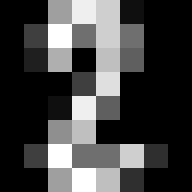
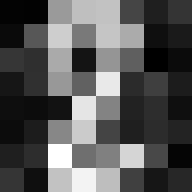

In [11]:
show_before_after(mnist_result, "Image - handwritten digit misread")

## Text - flip a review's sentiment

*From your seat: a content or sentiment filter is only as strong as its weakest
synonym.* Text has no smooth gradient to descend, so we switch algorithms. **PWWS**
(Probability-Weighted Word Saliency) ranks words by how much each one moves the
prediction, then swaps the most influential ones for synonyms until the sentiment
label flips - while keeping the sentence readable.

**Algorithm:** PWWS (Probability-Weighted Word Saliency) -
[Ren, Deng, He & Che, ACL 2019](https://aclanthology.org/P19-1103/).

### Step 1 - the original sample

In [12]:
imdb_env, imdb_url = await provision("ml-extraction-imdb-text")
imdb_spec = make_spec(imdb_url, num_classes=2, modality="text", name="Movie-review sentiment (text)")
imdb_original = httpx.get(f"{imdb_url}/members?n=1", timeout=30).json()["records"][0]
print("Original review - model sentiment verdict:")
print(imdb_original)

ml-extraction-imdb-text ready at https://8000-ioejnu9tq2kdbyn5pg0hg.sandbox.dreadnode.io
Original review - model sentiment verdict:
mr . bean , a bumbling security guard from england is sent to la to help with the grandiose homecoming of a masterpiece american painting . 
the first two words should have said enough to let you know what occurs during bean's trip to la , but if they didn't look out because you are in for a rather interesting if not odd ride . 
heck depending on your humor you might end up laughing through the whole flick . 
either way look out america bean is coming . 
well , what can really be said about this movie , there is very little discernible plot . 
that much is not hard to grapple with for it is a slapstick comedy . 
it achieves that goal rather admirably , but because it is that , the plot is just screaming for help . 
the whole premise that the movie is based on is to say the least flawed . 
the movie had its funny moments but there was no real story line oth

### Step 2 - the attack

In [13]:
async with Assessment("pwws_evasion - imdb - dreadnode-env"):
    imdb_result = await pwws_evasion(
        imdb_spec, imdb_original, num_classes=2, modality="text",
        max_queries=2000, seed=0, airt_target_model="Movie-review sentiment (text)",
    ).run()

### Step 3 - the adversarial sample + metrics

In [14]:
show_before_after(imdb_result, "Text - review sentiment flipped")


=== Text - review sentiment flipped ===
prediction:  0  ->  1   (evaded=True, tokens=0.0354, queries=1125)
original:    mr . bean , a bumbling security guard from england is sent to la to help with the grandiose homecoming of a masterpiece american painting . 
the first two words should have said enough to let you know what occurs during bean's trip to la , but if they didn't look out because you are in for a rather interesting if not odd ride . 
heck depending on your humor you might end up laughing through the whole flick . 
either way look out america bean is coming . 
well , what can really be said about this movie , there is very little discernible plot . 
that much is not hard to grapple with for it is a slapstick comedy . 
it achieves that goal rather admirably , but because it is that , the plot is just screaming for help . 
the whole premise that the movie is based on is to say the least flawed . 
the movie had its funny moments but there was no real story line other than som

## Read the findings

Open **[https://app.dreadnode.io](https://app.dreadnode.io)** -> your workspace -> project
**airt-learning-01-evasion**. Each run created an assessment named after the attack
and target; the finding detail shows the original vs. adversarial input, the
perturbation distance, and the query budget spent (`evaded=True` = fooled within
budget).

## Homework

- **Cheaper perturbation:** can you flip the label with a *smaller* distance
  (`l2_distance` / `linf_distance`)? Try raising `max_queries` - more search usually
  buys a smaller perturbation. Where does it plateau?
- **Fewer queries:** can you still succeed with `max_queries` halved? Plot
  success vs. budget to find the knee. A real target rate-limits you, so query
  efficiency *is* the attack.
- **Hardest modality:** which of tabular / image / text needed the most queries to
  flip, and why? Relate it to how each input space is shaped.

## Clean up

Hosted environments keep billing compute until you release them. Tear down everything this notebook provisioned:

In [15]:
for _e in _ENVS:
    await _e.teardown()
print(f"tore down {len(_ENVS)} environment(s)")

tore down 3 environment(s)


## Run it without a notebook (TUI + CLI)

Everything here is also driveable from the terminal - same platform, same findings:

- **TUI:** run `dreadnode` (no arguments) for the interactive terminal UI, pick the
  target and attack, and watch progress live.
- **Headless CLI:**

```bash
# $URL is the /predict endpoint the notebook printed when it provisioned
dn airt run-classifier --attack hopskipjump \\
  --endpoint $URL/predict --num-classes 2 --modality tabular --query-budget 600
```